# **Directed percolation in Rust-Python**

Demo simulation of directed percolation on a 1d lattice.

<hr>

## Preliminaries

In [428]:
from essentials import *
dprs.__version__

'2026.4.13'

In [429]:
viz = Viz(dpi=125)

<hr>

## Parameters

In [446]:
n_xy: int = 3000
n_iterations: int = 3000

expts_tuple = (
    dict(p_1=0.5383, p_2=0.9990,   p_3=0, scale=1.26),
    dict(p_1=0.5391, p_2=0.9900,   p_3=0, scale=1.26),
    dict(p_1=0.5497, p_2=0.8500,   p_3=0, scale=1.15),
    dict(p_1=0.5594, p_2=0.7000,   p_3=0, scale=0.98),
    dict(p_1=0.5671, p_2=0.5671,   p_3=0, scale=0.925),
    dict(p_1=0.5708, p_2=0.5000,   p_3=0, scale=0.89),
    dict(p_1=0.5806, p_2=0.3000,   p_3=0, scale=0.81),
    dict(p_1=0.5873, p_2=0.1500,   p_3=0, scale=0.76),
    dict(p_1=0.5934, p_2=0.0000,   p_3=0, scale=0.725),
)
expts = {i: expt for i, expt in enumerate(expts_tuple)}
expt = expts[4]
expt


{'p_1': 0.5671, 'p_2': 0.5671, 'p_3': 0, 'scale': 0.925}

In [431]:
class Parameters:
    growth_model = GrowthModel.Bedload
    dim = Dimension.D2
    n_x: int = n_xy
    n_y: int = n_xy
    n_z: int = 1
    p_1: float = expt["p_1"]
    p_2: float = expt["p_2"]
    p_3: float = expt["p_3"]
    n_iterations: int = n_iterations
    sample_period: int = 0
    random_seed: int = 5
    # initial_condition = InitialCondition.EdgeCell
    initial_condition = InitialCondition.Randomized
    p_initial: float = 0.99
    topology_x = Topology.Periodic
    topology_y = Topology.Periodic
    topology_z = Topology.Unspecified
    bcs_x = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_y = (BoundaryCondition.Floating, BoundaryCondition.Floating)
    bcs_z = (BoundaryCondition.Unspecified, BoundaryCondition.Unspecified)
    bc_values_x = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_y = (DUAL.OCCUPIED.state, DUAL.OCCUPIED.state)
    bc_values_z = (DUAL.EMPTY.state, DUAL.EMPTY.state)
    do_edge_buffering: bool = True
    processing = Processing.Parallel
    n_threads: int = 16
parameters = Parameters()

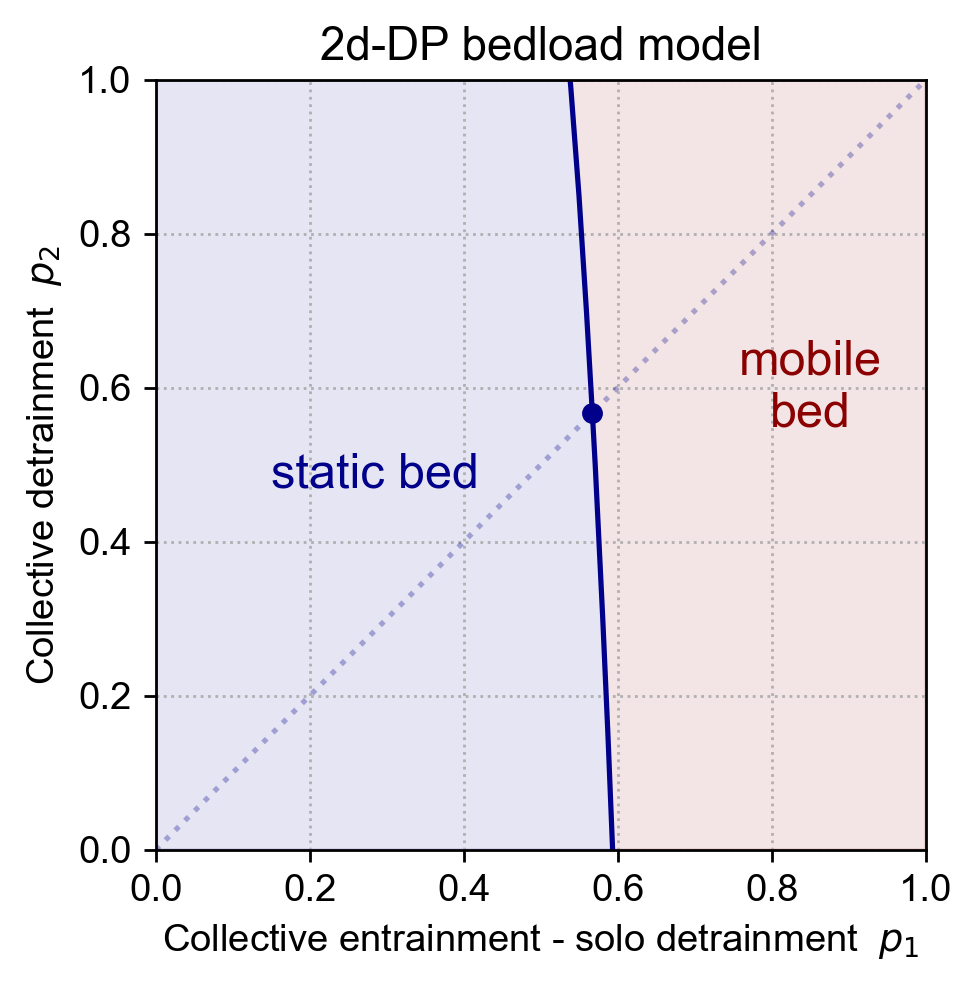

In [447]:
name = make_name(parameters, "phase_diagram",)
viz.create_figure(name, fig_size=(4., 4.))

p1_p2 = np.array([ (expt["p_1"], expt["p_2"]) for (key, expt,) in expts.items()]).T
p1 = np.concat([p1_p2[0, :], [p1_p2[0, -1]], [0, 0, p1_p2[0, 0], p1_p2[0, 0]]])
p2 = np.concat([p1_p2[1, :], [0], [0, 1, 1, p1_p2[1, 0]]])
p1c = np.concat([p1_p2[0, :], [p1_p2[0, -1]], [1, 1, p1_p2[0, 0], p1_p2[0, 0]]])
p2c = np.concat([p1_p2[1, :], [0], [0, 1, 1, p1_p2[1, 0]]])

# plt.plot(*p1_p2, "o", ms=3, color="DarkBlue",)
plt.plot(*p1_p2, "-", color="DarkBlue",)
plt.fill(p1, p2, color="DarkBlue", alpha=0.1,)
plt.fill(p1c, p2c, color="DarkRed", alpha=0.1,)
plt.plot((0,1), (0,1), ":", color="DarkBlue", alpha=0.3,)
sym_expt = expts[4]
plt.plot(sym_expt["p_1"], sym_expt["p_2"], "o", ms=5, color="DarkBlue",)
plt.xlim(0, 1,)
plt.ylim(0, 1,)
plt.xlabel(r"Collective entrainment - solo detrainment  $p_1$")
plt.ylabel(r"Collective detrainment  $p_2$")
axes = plt.gca()
axes.set_aspect(1)
plt.text(x=0.15, y=0.47, s="static bed", color="DarkBlue", font={"size": 14},)
plt.text(
    x=0.85, y=0.55, s="mobile\nbed", color="DarkRed", 
    horizontalalignment="center", font={"size": 14},
)
plt.title("2d-DP bedload model")
plt.grid(ls=":")
plt.show()

<hr>

## Simulation

Execute the Rust-coded sim (for small grids, parallelization can actually slow down the processing):

In [433]:
n_raw_lattices: int
raw_lattices: list[list[bool]] 
raw_tracking: Sequence[list]
pruned_tracking: Sequence[list]
t_run_time: float

In [434]:
(n_raw_lattices, raw_lattices, raw_tracking, t_run_time)= sim.dk(parameters)

In [435]:
print(f"Total number of lattice time slices = {n_raw_lattices}\n")

Total number of lattice time slices = 0



<hr>

## Post-processing

The function `sim.dk` returns a subset of the time-series of lattices generated by the simulation, with subsetting given by the `sample_rate` parameter, such that the total number provided is `n_lattices`. Each lattice is returned in flattened form as a 1d list, with all of them concatenated into one long 1d list.

In [436]:
n_lattices: int
lattices: NDArray
tracking: NDArray
(n_lattices, lattices, tracking) \
    = postprocessing(parameters, n_raw_lattices, raw_lattices, raw_tracking,)
lattices.shape

(0,)

<hr>

## Visualization

### Prep

In [437]:
i_slice: int
name: str

In [438]:
image_lattice = partial(
    viz.image_lattice,
    lattices=lattices, 
    p=parameters, 
    x=min(1000, parameters.n_x),
    y=min(1000, parameters.n_y),
    fig_size=(6, 4,),
)

### Evolution

In [439]:
if n_lattices>0:
    for i_slice in (20, 50, 100, 150, 200, 250,):
        name = make_name(parameters, "lattice", i_slice,)
        print(name)
        image_lattice(
            name=name, title=make_title(parameters, i_slice), i_lattice=i_slice,
        )
        plt.show()

### Mean order parameter $t$-decay

See Henkel et al (2008), tables 4.1 and 4.3: the mean order parameter (mean occupancy) $\overline\rho$ should decay with time as
$$
    \rho(t) \sim t^{-\delta}
$$
where in $d=2$ we should find $\delta \approx 0.4505$. 

ρmean_p0p570800_s5_nx3000_ny3000


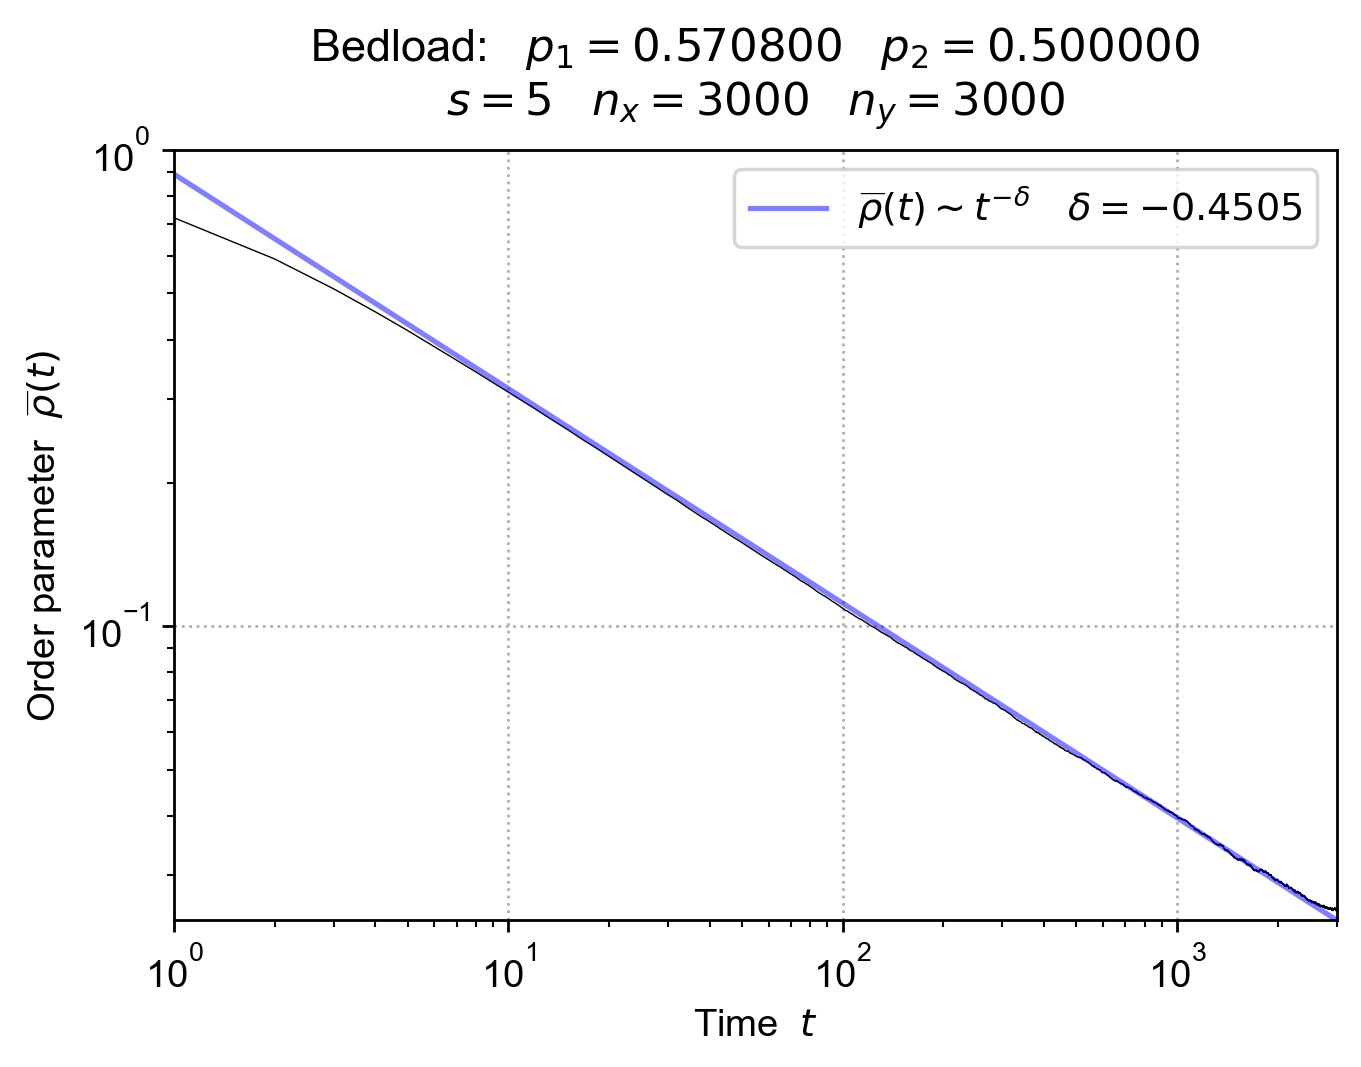

In [440]:
δ = 0.45051
scale = expt["scale"]
        
name = make_name(parameters, "ρmean", None, )
print(name)
viz.plot_lattice_statistic(
    name,
    make_title(parameters, None),
    tracking,
    choices=("time", "ρ_mean"),
    labels=(
        "Order parameter  $\\widebar{\\rho}(t)$", 
        "$\\widebar{\\rho}(t) \\sim t^{-\\delta}$",
        "${\\delta}$",
    ),
    exponent=-δ, 
    scale=scale,
    i_offset=0,
    do_ref_curve=True,
)
plt.ylim(None, 1)
plt.show()

In [441]:
i_offset: int = parameters.n_iterations//50
t: NDArray = tracking["time"][i_offset:]
ρ_mean: NDArray = tracking["ρ_mean"][i_offset:]
(exponent, scale, r_value, p_value, std_err) \
    = linregress(np.log(t), np.log(ρ_mean))
print(f"t range: {t[0]}-{t[-1]}")
print(rf"Estimated t-decay exponent:  δ = {exponent:0.3f}")

t range: 60.0-3000.0
Estimated t-decay exponent:  δ = -0.436


<hr>

## Export

In [448]:
plots_dir: str = create_directories((os.path.curdir,"plots",), "bedload2d")
export_plots(
    viz.fdict,
    plots_dir,
    "PNG",
    suffix="",
    dpi=150,
)

'././plots/bedload2d'